# Cardiac arrest early-warning system — pipeline experiment

Single-notebook pipeline from data to evaluation, per `cardiac_arrest_ews_plan.md`.
This notebook implements **sections 0–8 + 10** — config, data inventory, cohort/labels, preprocessing, engineered features, baselines, foundation-model embeddings (ECG-FM + PaPaGei), the Wav2Arrest-style temporal risk model, ablations, full alert evaluation on held-out patients, and export. (Section 9, the optional slow-risk layer, is skipped: see its note.)

**Research prototype only. Nothing here is validated for clinical use.**

**How to run:** execute all cells top to bottom with `USE_SYNTHETIC=True` (default — no credentials or downloads needed). Cached artifacts land in `cache/`, figures and metrics in `outputs/`. The notebook is re-runnable from any section; expensive steps are cached.


## Section 0 — Config and environment check

One config cell (edit only this), then an environment check that prints what is present and what is missing. Missing third-party assets only matter from Section 6 onward.


In [1]:
from pathlib import Path

# ----------------------------------------------------------------------
# Section 0 - Configuration
# Everything downstream reads from this cell. Edit values here only.
# ----------------------------------------------------------------------

USE_SYNTHETIC = True            # run end-to-end on generated data (no credentials / downloads)
RANDOM_SEED = 42

# --- Early-warning horizons (hours) -----------------------------------
HORIZONS = [1, 6, 24]

# --- Signals, rates, segmentation -------------------------------------
MONITOR_FS = 125.0              # native synthetic monitor rate (Hz), MIMIC-style
SEGMENT_LEN_S = 30              # seconds per segment fed to the foundation encoders
WINDOW_MIN = 5                  # aggregation window for features and labels (minutes)
ENCODER_FS = {"ecg": 500.0, "ppg": 125.0}   # resample targets per encoder (Section 3+)

# --- Synthetic cohort --------------------------------------------------
N_PATIENTS = 60
P_ARREST = 0.5                  # fraction of synthetic patients with an arrest event
STAY_MIN_H, STAY_MAX_H = 24.0, 96.0
ARREST_MIN_H, ARREST_MAX_H = 12.0, 72.0   # arrest time within the stay (hours)
DRIFT_H = 6.0                   # hours of pre-arrest physiological drift
EXCLUDE_BEFORE_ARREST_MIN = 15  # minutes before arrest: excluded ("clinicians already responding")
P_MISSING_PPG = 0.10            # fraction of patients without a PPG stream (different monitor)

# --- Splits ------------------------------------------------------------
N_FOLDS = 5
TEMPORAL_HOLDOUT_FRAC = 0.2     # latest-admitted patients held out (temporal evaluation)

# --- Paths -------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"          # real records (own data / MIMIC) — never committed
CACHE_DIR = PROJECT_ROOT / "cache"        # all cached intermediates
EMBED_DIR = CACHE_DIR / "embeddings"      # cached encoder embeddings (Section 6)
OUTPUT_DIR = PROJECT_ROOT / "outputs"     # metrics, figures, config dumps
THIRD_PARTY_DIR = PROJECT_ROOT / "third_party"   # cloned repos
WEIGHTS_DIR = PROJECT_ROOT / "weights"    # model weights — never committed

# Embedding extraction runs in separate conda envs via subprocess (plan section 4).
# Only needed from Section 6 onward; sections 0-3 ignore these.
EMBED_ENVS = {"ecg": "ecgfm_env", "ppg": "papagei_env"}

for _d in (DATA_DIR, CACHE_DIR, EMBED_DIR, OUTPUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

print(f"USE_SYNTHETIC = {USE_SYNTHETIC}   seed = {RANDOM_SEED}   horizons = {HORIZONS} h")
print(f"project root  = {PROJECT_ROOT}")


USE_SYNTHETIC = True   seed = 42   horizons = [1, 6, 24] h
project root  = /home/abrar/Desktop/AI RPM Papers/Cardiac Arrest Detection


In [2]:
import subprocess
import sys
from pathlib import Path

print(f"Python {sys.version.split()[0]}  |  {sys.executable}")

# --- core packages (needed for sections 0-8) --------------------------------
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn

print("\nCore packages:")
for name, mod in [("numpy", np), ("pandas", pd), ("scipy", scipy),
                  ("scikit-learn", sklearn), ("matplotlib", matplotlib)]:
    print(f"  {name:<12} {mod.__version__}")

# Optional in synthetic mode: wfdb = real MIMIC records, lifelines = Section 7 survival
for name in ("wfdb", "lifelines"):
    try:
        mod = __import__(name)
        print(f"  {name:<12} {getattr(mod, '__version__', 'installed')}")
    except ImportError:
        print(f"  {name:<12} MISSING (needed for real-data mode / Section 7 only)")

# --- third-party repos and weights (required from Section 6 onward) -----------
def repo_commit(path: Path) -> str:
    """Short git commit hash of a repo path, or a status string (plan rule 10)."""
    p = Path(path)
    if not p.exists():
        return "MISSING"
    try:
        out = subprocess.run(["git", "rev-parse", "HEAD"], cwd=p,
                             capture_output=True, text=True, check=True)
        return "ok " + out.stdout.strip()[:8]
    except Exception:
        return "present, no git metadata"

print("\nThird-party assets (required from Section 6 onward):")
for label, p in [
    ("ecg-fm repo", THIRD_PARTY_DIR / "ecg-fm"),
    ("fairseq-signals repo", THIRD_PARTY_DIR / "fairseq-signals"),
    ("papagei repo", THIRD_PARTY_DIR / "papagei-foundation-model"),
    ("pulseppg repo", THIRD_PARTY_DIR / "pulseppg"),
    ("ECG-FM weights", WEIGHTS_DIR / "mimic_iv_ecg_physionet_pretrained.pt"),
    ("PaPaGei weights", WEIGHTS_DIR / "papagei_s.pt"),
]:
    print(f"  {label:<24} {repo_commit(p)}")

if USE_SYNTHETIC:
    print("\nSYNTHETIC MODE: sections 0-5 need no third-party assets.")
else:
    print("\nREAL-DATA MODE: requires credentialed PhysioNet access and data in DATA_DIR.")

# --- plot color constants (dataviz reference palette; arrest marker uses
#     status-critical) ---------------------------------------------------------
COLORS = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a",
          "violet": "#4a3aa7", "critical": "#d03b3b"}

# --- seed everything -----------------------------------------------------------
rng = np.random.default_rng(RANDOM_SEED)
print(f"\nnumpy Generator seeded with {RANDOM_SEED}")


Python 3.13.7  |  /home/abrar/anaconda3/envs/pyprime/bin/python



Core packages:
  numpy        2.4.3
  pandas       2.2.3
  scipy        1.15.3
  scikit-learn 1.5.2
  matplotlib   3.10.6
  wfdb         4.3.1
  lifelines    MISSING (needed for real-data mode / Section 7 only)

Third-party assets (required from Section 6 onward):
  ecg-fm repo              ok 9f926f19
  fairseq-signals repo     ok f8f0ff1c
  papagei repo             ok 0c537dad
  pulseppg repo            ok 716eaf9c
  ECG-FM weights           present, no git metadata
  PaPaGei weights          present, no git metadata

SYNTHETIC MODE: sections 0-5 need no third-party assets.

numpy Generator seeded with 42


## Section 1 — Data access and inventory

Synthetic mode generates a monitor-style cohort: per-patient 5-minute vitals trajectories (HR, SBP, DBP, SpO₂) with pre-arrest drift, plus on-demand 30 s waveform segments (ECG, PPG, ABP at 125 Hz) with injected artifacts. Real-data mode would load records with `wfdb` (requires credentialed PhysioNet access — not implemented here).

The vitals table is the backbone of sections 2–5; waveform segments feed the foundation encoders in Section 6.


In [3]:
# Synthetic waveform synthesizers live in scripts/synth_signals.py so the
# embedding-extraction scripts (Section 6) share the same generators.

import sys

sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

from synth_signals import generate_waveform_segment  # noqa: E402

# API (see scripts/synth_signals.py for details):
#   generate_waveform_segment(hr, sbp, dbp, amp_ecg, amp_ppg, pt_ms,
#                             fs=MONITOR_FS, dur_s=SEGMENT_LEN_S, seed=...)
#   -> {"ecg": (n,), "ppg": (n,), "abp": (n,)} float32 arrays; missing streams NaN


In [4]:
# ---------------------------------------------------------------------------
# Synthetic cohort: per-patient 5-minute vitals trajectories with pre-arrest
# drift, ground-truth stream-quality flags, and an arrest event table.
# Cached under cache/ so every later section re-runs from disk.
# ---------------------------------------------------------------------------

CACHE_VITALS = CACHE_DIR / "synthetic_vitals.parquet"
CACHE_EVENTS = CACHE_DIR / "synthetic_events.csv"


def _draw_qf(rs):
    """Random ground-truth quality flag for one stream-window (the Section 3
    gate must recover these from the waveform alone)."""
    r = rs.random()
    if r < 0.02:
        return "flat"
    if r < 0.03:
        return "sat"
    if r < 0.05:
        return "noise"
    return "ok"


def build_synthetic_cohort(seed=RANDOM_SEED, force=False):
    """Generate vitals trajectories + arrest events. Returns (vitals, events)."""
    if not force and CACHE_VITALS.exists() and CACHE_EVENTS.exists():
        vitals = pd.read_parquet(CACHE_VITALS)
        events = pd.read_csv(CACHE_EVENTS)
        print(f"loaded cached cohort: {len(vitals):,} windows, {len(events)} events "
              f"(delete cache/ or pass force=True to rebuild)")
        return vitals, events

    rs = np.random.default_rng(seed)
    rows, event_rows = [], []
    win_h = WINDOW_MIN / 60.0

    for pid in range(N_PATIENTS):
        stay_h = rs.uniform(STAY_MIN_H, STAY_MAX_H)
        admit_h = rs.uniform(0.0, 365.0 * 24.0)     # admission time within a year
        is_case = bool(rs.random() < P_ARREST)
        has_ppg = bool(rs.random() >= P_MISSING_PPG)
        arrest_h = None
        if is_case:
            arrest_h = rs.uniform(ARREST_MIN_H, min(ARREST_MAX_H, stay_h - 0.5))

        hr0 = rs.normal(78, 6); sbp0 = rs.normal(126, 8)
        dbp0 = rs.normal(76, 6); spo0 = rs.normal(97.5, 1.0)
        phase = rs.uniform(0.0, 2.0 * np.pi)

        t = 0.0
        while t < stay_h:
            hr = hr0 + 3.0 * np.sin(2 * np.pi * t / 8.0 + phase) + rs.normal(0, 1.5)
            sbp = sbp0 + 6.0 * np.sin(2 * np.pi * t / 12.0 + phase) + rs.normal(0, 3.0)
            dbp = dbp0 + 3.0 * np.sin(2 * np.pi * t / 12.0 + phase) + rs.normal(0, 2.0)
            spo2 = spo0 + rs.normal(0, 0.4)
            amp_ppg = 1.0 if has_ppg else np.nan
            pt_ms, rrsd = 250.0, 0.04

            if is_case and (arrest_h - t) <= DRIFT_H and t < arrest_h:
                p = (1.0 - (arrest_h - t) / DRIFT_H) ** 2      # 0 -> 1 approaching arrest
                hr += 55.0 * p
                sbp -= 45.0 * p
                dbp -= 25.0 * p
                spo2 -= 12.0 * p
                amp_ppg *= 1.0 - 0.6 * p
                pt_ms += 70.0 * p
                rrsd = max(0.008, rrsd - 0.025 * p)

            if is_case and t >= arrest_h:
                # post-arrest: disorganized signal, excluded downstream (plan rule 4)
                hr, sbp = rs.uniform(30, 170), rs.uniform(60, 110)
                dbp, spo2 = rs.uniform(30, 70), rs.uniform(70, 95)
                amp_ppg = 0.1 if has_ppg else np.nan
                rrsd = rs.uniform(0.02, 0.15)

            rows.append(dict(
                patient_id=pid, is_case=is_case, has_ppg=has_ppg,
                stay_h=stay_h, admit_h=admit_h, arrest_h=arrest_h,
                t_start_h=round(t, 4), t_end_h=round(t + win_h, 4),
                hr=hr, sbp=sbp, dbp=dbp, spo2=spo2,
                amp_ppg=amp_ppg, pt_ms=pt_ms, rrsd=rrsd,
                qf_ecg=_draw_qf(rs), qf_ppg=_draw_qf(rs) if has_ppg else "missing",
                qf_abp=_draw_qf(rs),
            ))
            t += win_h

        if is_case:
            event_rows.append(dict(patient_id=pid, arrest_time_h=round(arrest_h, 4),
                                   stay_start_epoch_h=round(admit_h, 4), source="synthetic"))

    vitals = pd.DataFrame(rows)
    events = pd.DataFrame(event_rows)
    vitals.to_parquet(CACHE_VITALS, index=False)
    events.to_csv(CACHE_EVENTS, index=False)
    print(f"built cohort: {len(vitals):,} windows, {len(events)} events -> cache/")
    return vitals, events


vitals, events = build_synthetic_cohort()
vitals.head()


loaded cached cohort: 42,261 windows, 28 events (delete cache/ or pass force=True to rebuild)


,patient_id,is_case,has_ppg,stay_h,admit_h,arrest_h,t_start_h,t_end_h,hr,sbp,dbp,spo2,amp_ppg,pt_ms,rrsd,qf_ecg,qf_ppg,qf_abp
0,0,False,True,79.724835,3844.575132,NaN,0.0000,0.0833,67.176635,122.545582,80.485039,97.210170,1.0,250.0,0.04,ok,ok,ok
1,0,False,True,79.724835,3844.575132,NaN,0.0833,0.1667,69.140698,117.208030,80.775000,97.163787,1.0,250.0,0.04,ok,ok,ok
2,0,False,True,79.724835,3844.575132,NaN,0.1667,0.2500,68.477326,118.968414,78.398192,97.396681,1.0,250.0,0.04,noise,ok,ok
3,0,False,True,79.724835,3844.575132,NaN,0.2500,0.3333,72.032796,119.193981,78.157888,96.858248,1.0,250.0,0.04,ok,ok,ok
4,0,False,True,79.724835,3844.575132,NaN,0.3333,0.4167,67.660477,118.090415,80.558875,97.481059,1.0,250.0,0.04,ok,ok,ok


In [5]:
# ---------------------------------------------------------------------------
# Data inventory: what exists per patient (streams, rate, duration, windows).
# Real-data mode (USE_SYNTHETIC=False) would fill the same table from wfdb
# records - not implemented, needs credentialed PhysioNet access.
# ---------------------------------------------------------------------------

inv_rows = []
for pid, g in vitals.groupby("patient_id"):
    inv_rows.append(dict(
        patient_id=pid,
        is_case=bool(g["is_case"].iloc[0]),
        stay_h=round(float(g["stay_h"].iloc[0]), 1),
        n_windows=int(len(g)),
        ecg=True,                       # synthetic monitors always carry ECG
        ppg=bool(g["has_ppg"].iloc[0]),
        abp=True,
        fs_hz=MONITOR_FS,
        arrest_h=(round(float(g["arrest_h"].iloc[0]), 1) if bool(g["is_case"].iloc[0]) else None),
    ))
inventory = pd.DataFrame(inv_rows)

n_cases = int(inventory["is_case"].sum())
print("Cohort inventory (synthetic)")
print(f"  patients           : {len(inventory)}")
print(f"  cases / events     : {n_cases} / {len(events)}")
print(f"  total 5-min windows: {len(vitals):,}")
print(f"  sampling rate      : {MONITOR_FS:.0f} Hz on all streams")
print(f"  ECG present        : {int(inventory['ecg'].sum())}/{len(inventory)} patients")
print(f"  PPG present        : {int(inventory['ppg'].sum())}/{len(inventory)} patients")
print(f"  ABP present        : {int(inventory['abp'].sum())}/{len(inventory)} patients")
print(f"  stay duration      : median {inventory['stay_h'].median():.1f} h "
      f"[{inventory['stay_h'].min():.0f}, {inventory['stay_h'].max():.0f}] h")
print()
inventory[["patient_id", "is_case", "stay_h", "n_windows", "ecg", "ppg", "abp",
           "fs_hz", "arrest_h"]].head(8)


Cohort inventory (synthetic)
  patients           : 60
  cases / events     : 28 / 28
  total 5-min windows: 42,261
  sampling rate      : 125 Hz on all streams
  ECG present        : 60/60 patients
  PPG present        : 54/60 patients
  ABP present        : 60/60 patients
  stay duration      : median 55.8 h [24, 95] h



,patient_id,is_case,stay_h,n_windows,ecg,ppg,abp,fs_hz,arrest_h
0,0,False,79.7,957,True,True,True,125.0,NaN
1,1,False,35.4,425,True,True,True,125.0,NaN
2,2,True,55.7,669,True,True,True,125.0,39.2
3,3,False,92.5,1111,True,True,True,125.0,NaN
4,4,True,43.6,524,True,True,True,125.0,23.2
5,5,True,48.0,576,True,True,True,125.0,26.4
6,6,True,41.8,503,True,True,True,125.0,22.5
7,7,True,84.3,1012,True,False,True,125.0,15.8


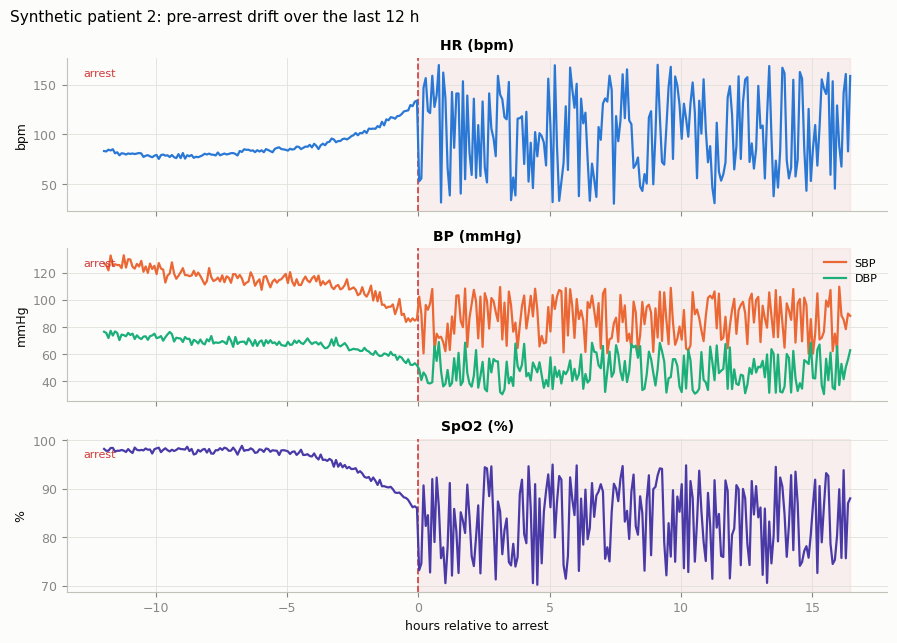

In [6]:
# ---------------------------------------------------------------------------
# Sanity figure: one case patient's last 12 h (HR, BP, SpO2), showing the
# injected pre-arrest drift. Post-arrest region is shaded (excluded downstream).
# Colors from the dataviz reference palette; no dual-axis panels.
# ---------------------------------------------------------------------------
SURF, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold",
    "lines.linewidth": 1.6,
})

pid = int(events["patient_id"].iloc[0])
arrest_h = float(events.loc[events["patient_id"] == pid, "arrest_time_h"].iloc[0])
traj = vitals[(vitals["patient_id"] == pid) & (vitals["t_start_h"] >= arrest_h - 12)]
traj = traj.sort_values("t_start_h")
t_rel = traj["t_start_h"].to_numpy() - arrest_h

fig, axes = plt.subplots(3, 1, figsize=(9, 6.5), sharex=True)
for ax in axes:
    ax.axvspan(0.0, float(t_rel.max()), color=COLORS["critical"], alpha=0.07)
    ax.axvline(0.0, color=COLORS["critical"], linewidth=1.2, linestyle="--")
    ax.text(0.02, 0.88, "arrest", transform=ax.transAxes,
            color=COLORS["critical"], fontsize=8)

axes[0].plot(t_rel, traj["hr"], color=COLORS["blue"])
axes[0].set_title("HR (bpm)")
axes[0].set_ylabel("bpm")

axes[1].plot(t_rel, traj["sbp"], color=COLORS["orange"], label="SBP")
axes[1].plot(t_rel, traj["dbp"], color=COLORS["aqua"], label="DBP")
axes[1].set_title("BP (mmHg)")
axes[1].set_ylabel("mmHg")
axes[1].legend(loc="upper right", frameon=False, fontsize=8)

axes[2].plot(t_rel, traj["spo2"], color=COLORS["violet"])
axes[2].set_title("SpO2 (%)")
axes[2].set_ylabel("%")
axes[2].set_xlabel("hours relative to arrest")

fig.suptitle(f"Synthetic patient {pid}: pre-arrest drift over the last 12 h",
             fontsize=11, x=0.01, ha="left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "sanity_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 2 — Cohort and labels

Arrest event table, control-window sampling in two schemes (random across the stay vs. last 24 h — the latter is the known-bias variant we report for comparison), per-horizon binary labels plus a time-to-event (TTE) regression target.

Excluded windows (post-arrest, and the "already responding" floor before arrest) stay in the table with `excluded_reason` set and labels `NaN`, so downstream code can assert the exclusions are actually applied (plan rule 4).


In [7]:
# Window-level labels: for each horizon H in HORIZONS, a binary "arrest within
# the next H hours" label plus time-to-arrest for the regression head.

def build_labels(vitals, events, scheme, max_windows_per_patient=None,
                 rng_seed=RANDOM_SEED):
    """Sample 5-min windows and attach labels.

    scheme = 'random_stay' : all eligible windows across the whole stay
    scheme = 'last_24h'    : controls -> last 24 h of stay; cases -> last 24 h before arrest
    """
    assert scheme in ("random_stay", "last_24h")
    rs = np.random.default_rng(rng_seed)
    out, excl = [], []
    floor_h = EXCLUDE_BEFORE_ARREST_MIN / 60.0

    for pid, g in vitals.groupby("patient_id"):
        is_case = bool(g["is_case"].iloc[0])
        stay_h = g["stay_h"].iloc[0]
        arrest_h = g["arrest_h"].iloc[0]
        g = g.sort_values("t_start_h")

        if is_case:
            assert np.isfinite(arrest_h), f"case patient {pid} has no arrest time"
            t_max = arrest_h - floor_h        # windows must end before this
        else:
            t_max = stay_h

        if scheme == "last_24h":
            lo = max(0.0, (arrest_h - 24.0) if is_case else (stay_h - 24.0))
        else:
            lo = 0.0

        sel = g[(g["t_start_h"] >= lo) & (g["t_end_h"] <= t_max)]
        if max_windows_per_patient and len(sel) > max_windows_per_patient:
            sel = sel.iloc[rs.choice(len(sel), size=max_windows_per_patient, replace=False)]
        if len(sel) == 0:
            continue

        sub = sel.copy()
        sub["scheme"] = scheme
        for H in HORIZONS:
            if is_case:
                tte = arrest_h - sub["t_end_h"].to_numpy()
                sub[f"label_{H}h"] = ((tte > 0) & (tte <= H)).astype(int)
            else:
                sub[f"label_{H}h"] = 0
        if is_case:
            sub["tte_h"] = arrest_h - sub["t_end_h"]
            sub["tte_censored"] = 0
        else:
            sub["tte_h"] = np.nan
            sub["tte_censored"] = 1
        sub["excluded_reason"] = ""
        out.append(sub)

    # post-arrest / "already responding" windows: kept, excluded, labels NaN
    for pid, g in vitals.groupby("patient_id"):
        if not bool(g["is_case"].iloc[0]):
            continue
        arrest_h = g["arrest_h"].iloc[0]
        lo = arrest_h - floor_h
        g = g[(g["t_start_h"] >= lo - 1e-9) & (g["t_start_h"] < g["stay_h"])]
        if len(g) == 0:
            continue
        g = g.copy()
        g["scheme"] = scheme
        for H in HORIZONS:
            g[f"label_{H}h"] = np.nan
        g["tte_h"] = np.nan
        g["tte_censored"] = np.nan
        g["excluded_reason"] = np.where(g["t_end_h"] <= arrest_h, "responding", "post_arrest")
        excl.append(g)

    return pd.concat(out + excl, ignore_index=True)


In [8]:
# ---------------------------------------------------------------------------
# Label summary: class counts per horizon and scheme, plus sanity assertions.
# ---------------------------------------------------------------------------

print("Arrest event table (synthetic):")
display(events)

labels = {s: build_labels(vitals, events, s) for s in ("random_stay", "last_24h")}
print()
for s, df in labels.items():
    n_ex = int((df["excluded_reason"] != "").sum())
    print(f"scheme = {s}: {len(df):,} windows ({n_ex:,} excluded)")
    for H in HORIZONS:
        col = f"label_{H}h"
        n_pos = int(df[col].fillna(0).sum())
        n_neg = int((df[col] == 0).sum())
        prev = n_pos / max(1, n_pos + n_neg)
        print(f"  horizon {H:>2} h: positive {n_pos:>6}  negative {n_neg:>6}  prevalence {prev:.4f}")
    print()

# assertions (plan rules 2 and 4)
for s, df in labels.items():
    assert df.loc[df["excluded_reason"] != "", f"label_{HORIZONS[0]}h"].isna().all(), \
        f"{s}: excluded windows must not carry labels"
    tte = df.loc[df["tte_h"].notna(), "tte_h"]
    assert (tte > 0).all(), f"{s}: time-to-event must be positive"
print("label sanity checks passed")


Arrest event table (synthetic):


,patient_id,arrest_time_h,stay_start_epoch_h,source
0,2,39.2210,6725.5469,synthetic
1,4,23.1906,8597.1564,synthetic
2,5,26.3922,5890.3652,synthetic
3,6,22.5449,7978.9474,synthetic
4,7,15.7917,907.2413,synthetic
5,8,42.3228,4462.6301,synthetic
6,15,17.6682,7161.0351,synthetic
7,17,20.0755,2849.1563,synthetic
8,18,29.1915,8006.2937,synthetic
9,20,24.4399,61.4742,synthetic



scheme = random_stay: 42,201 windows (7,889 excluded)
  horizon  1 h: positive    252  negative  34060  prevalence 0.0073
  horizon  6 h: positive   1932  negative  32380  prevalence 0.0563
  horizon 24 h: positive   7509  negative  26803  prevalence 0.2188

scheme = last_24h: 24,562 windows (7,889 excluded)
  horizon  1 h: positive    252  negative  16421  prevalence 0.0151
  horizon  6 h: positive   1932  negative  14741  prevalence 0.1159
  horizon 24 h: positive   7489  negative   9184  prevalence 0.4492

label sanity checks passed


## Section 3 — Preprocessing

1. **Synchronization/resampling**: all synthetic streams share one clock at 125 Hz; `resample_signal` implements the per-encoder targets (ECG → 500 Hz by linear interpolation, matching ECG-FM's own preprocessing; decimation uses anti-aliased polyphase resampling).
2. **Quality gate** per stream per segment: flatline, saturation, SNR heuristic.
3. **Segment cutting**: 30 s segments per window, deterministic per (patient, window) so Section 6 can regenerate and cache embeddings per window.
4. **Patient-level splits**: grouped K-fold stratified by case/control, plus a temporal hold-out by admission time. No patient may appear in more than one split (plan rule 2).


In [9]:
from fractions import Fraction

from scipy.signal import resample_poly

# ---------------------------------------------------------------------------
# Preprocessing primitives: resampling per encoder target, per-stream quality
# gate, and deterministic segment cutting (with artifact injection).
# cut_segment / inject_artifact live in scripts/synth_signals.py (shared with
# the Section 6 embedding pipeline); resampling and the quality gate stay here.
# ---------------------------------------------------------------------------

from synth_signals import cut_segment, inject_artifact  # noqa: E402

def resample_signal(x, fs_in, fs_out):
    """Resample x from fs_in to fs_out.

    Upsampling uses linear interpolation (ECG-FM's own preprocessing does the
    same); decimation uses polyphase resampling with anti-aliasing.
    """
    x = np.asarray(x, dtype=np.float64)
    if np.isnan(x).all():
        n_out = int(round(len(x) * fs_out / fs_in))
        return np.full(n_out, np.nan)
    if fs_out == fs_in:
        return x.copy()
    if fs_out > fs_in:
        t_in = np.arange(len(x)) / fs_in
        t_out = np.arange(int(round(len(x) * fs_out / fs_in))) / fs_out
        return np.interp(t_out, t_in, x)
    f = Fraction(fs_out / fs_in).limit_denominator(1000)
    return resample_poly(x, f.numerator, f.denominator)


def _band_power(x, fs, lo, hi):
    f = np.fft.rfftfreq(len(x), d=1.0 / fs)
    p = np.abs(np.fft.rfft(x - np.nanmean(x))) ** 2
    m = (f >= lo) & (f < hi)
    return p[m].sum() if m.any() else 0.0


def quality_gate(x, fs, sat_frac=0.05, snr_thresh=2.0):
    """Rule-based per-stream quality gate. Returns (passed: bool, flags: dict).

    Flatline: std below 1e-4. Saturation: >sat_frac of samples pinned at the
    ADC rails. SNR: physiological band power (0.5-12 Hz) vs high-frequency
    band power (30 Hz - Nyquist). Missing streams fail with flags['missing'].
    """
    flags = {"flatline": False, "saturation": False, "snr_low": False, "missing": False}
    x = np.asarray(x, dtype=np.float64)
    if np.isnan(x).all():
        flags["missing"] = True
        return False, flags
    if float(np.nanstd(x)) < 1e-4:
        flags["flatline"] = True
        return False, flags
    xmax, xmin = np.nanmax(x), np.nanmin(x)
    pinned = np.mean((np.abs(x - xmax) < 1e-6) | (np.abs(x - xmin) < 1e-6))
    flags["saturation"] = bool(pinned > sat_frac)
    p_sig = _band_power(x, fs, 0.5, 12.0)
    p_noise = _band_power(x, fs, 30.0, min(60.0, fs / 2.0))
    flags["snr_low"] = bool(p_sig / (p_noise + 1e-12) < snr_thresh)
    passed = not (flags["saturation"] or flags["snr_low"])
    return passed, flags


# quick self-test of the resampler on a clean segment
ok_row = vitals[vitals["qf_ecg"] == "ok"].iloc[0]
seg_test = cut_segment(ok_row["patient_id"], ok_row["t_start_h"], ok_row)
x500 = resample_signal(seg_test["ecg"], MONITOR_FS, ENCODER_FS["ecg"])
print(f"resample demo: ECG {MONITOR_FS:.0f} -> {ENCODER_FS['ecg']:.0f} Hz: "
      f"{len(seg_test['ecg'])} -> {len(x500)} samples")
assert len(x500) == int(round(len(seg_test["ecg"]) * ENCODER_FS["ecg"] / MONITOR_FS))
print("ok")


resample demo: ECG 125 -> 500 Hz: 3750 -> 15000 samples
ok


In [10]:
# ---------------------------------------------------------------------------
# Segment-cutting demo: cut 30 s segments for a small set of windows, run the
# per-stream quality gate, and compare against the injected ground-truth flags.
# ---------------------------------------------------------------------------

rows_sel = []
for pid in events["patient_id"].unique()[:2]:
    g = vitals[vitals["patient_id"] == pid].sort_values("t_start_h")
    a_h = g["arrest_h"].iloc[0]
    far = g[g["t_start_h"] < a_h - 8.0].iloc[0]
    near = g[(g["t_start_h"] < a_h - 0.5) & (g["t_start_h"] >= a_h - 2.0)].iloc[-1]
    rows_sel += [far, near]
for pid in vitals.loc[~vitals["is_case"], "patient_id"].unique()[:2]:
    rows_sel.append(vitals[vitals["patient_id"] == pid].iloc[0])
for q in ("flat", "sat", "noise"):
    m = vitals[(vitals["qf_ecg"] == q) | (vitals["qf_ppg"] == q) | (vitals["qf_abp"] == q)]
    if len(m):
        rows_sel.append(m.iloc[0])

recs = []
for r in rows_sel:
    seg = cut_segment(r["patient_id"], r["t_start_h"], r)
    for stream in ("ecg", "ppg", "abp"):
        passed, flags = quality_gate(seg[stream], MONITOR_FS)
        recs.append(dict(patient=int(r["patient_id"]), t_h=r["t_start_h"],
                         stream=stream, truth=r[f"qf_{stream}"], passed=passed, **flags))
qgate = pd.DataFrame(recs)

print(f"quality gate on {len(rows_sel)} demo windows x 3 streams "
      f"(rows: injected truth, columns: gate verdict):")
print(pd.crosstab(qgate["truth"], qgate["passed"].rename("gate_passed")))
missed = qgate[(qgate["truth"] != "ok") & (qgate["passed"])]
if len(missed):
    print("\nGATE MISSES (artifact present but gate passed):")
    print(missed)
print()
qgate


quality gate on 9 demo windows x 3 streams (rows: injected truth, columns: gate verdict):


gate_passed  False  True 
truth                    
flat             1      0
noise            1      0
ok               0     23
sat              2      0



,patient,t_h,stream,truth,passed,flatline,saturation,snr_low,missing
0,2,0.0000,ecg,ok,True,False,False,False,False
1,2,0.0000,ppg,ok,True,False,False,False,False
2,2,0.0000,abp,ok,True,False,False,False,False
3,2,38.6667,ecg,ok,True,False,False,False,False
4,2,38.6667,ppg,ok,True,False,False,False,False
5,2,38.6667,abp,ok,True,False,False,False,False
6,4,0.0000,ecg,ok,True,False,False,False,False
7,4,0.0000,ppg,ok,True,False,False,False,False
8,4,0.0000,abp,ok,True,False,False,False,False
9,4,22.6667,ecg,ok,True,False,False,False,False


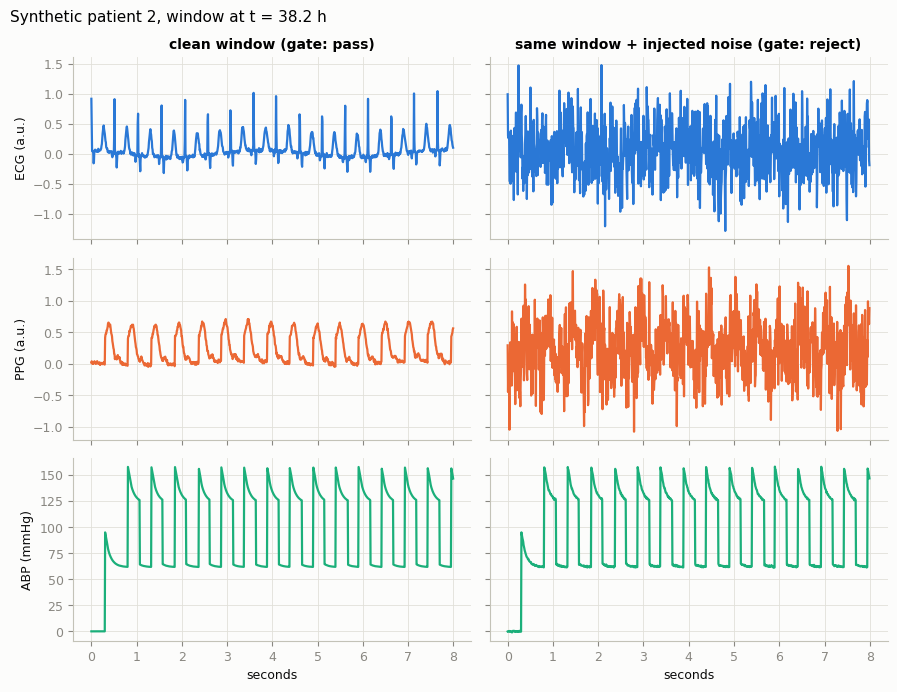

In [11]:
# ---------------------------------------------------------------------------
# Waveform demo: the same window clean vs with injected noise, to show what
# the quality gate rejects. (Flat/sat rows appear in the gate table above.)
# ---------------------------------------------------------------------------

demo_cands = [int(p) for p in events["patient_id"]
              if bool(vitals.loc[vitals["patient_id"] == p, "has_ppg"].iloc[0])]
assert demo_cands, "no event patient with a PPG stream in the synthetic cohort"
demo_pid = demo_cands[0]
arrest_demo = float(vitals.loc[vitals["patient_id"] == demo_pid, "arrest_h"].iloc[0])

win_row = vitals[(vitals["patient_id"] == demo_pid) & (vitals["qf_ecg"] == "ok") &
                 (vitals["t_start_h"] < arrest_demo - 1.0)].sort_values("t_start_h").iloc[-1]
seg = cut_segment(demo_pid, win_row["t_start_h"], win_row)
row_noise = win_row.copy()
row_noise[["qf_ecg", "qf_ppg", "qf_abp"]] = "noise"
seg_n = cut_segment(demo_pid, win_row["t_start_h"], row_noise)

fig, axes = plt.subplots(3, 2, figsize=(9, 7), sharex="col", sharey="row")
streams = [("ecg", "ECG (a.u.)", COLORS["blue"]),
           ("ppg", "PPG (a.u.)", COLORS["orange"]),
           ("abp", "ABP (mmHg)", COLORS["aqua"])]
for i, (key, label, color) in enumerate(streams):
    x = np.arange(len(seg[key])) / MONITOR_FS
    m = x < 8.0
    axes[i, 0].plot(x[m], seg[key][m], color=color)
    axes[i, 1].plot(x[m], seg_n[key][m], color=color)
    axes[i, 0].set_ylabel(label)
axes[0, 0].set_title("clean window (gate: pass)")
axes[0, 1].set_title("same window + injected noise (gate: reject)")
for ax in axes[-1, :]:
    ax.set_xlabel("seconds")
fig.suptitle(f"Synthetic patient {demo_pid}, window at t = {win_row['t_start_h']:.1f} h",
             fontsize=11, x=0.01, ha="left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "sanity_waveforms.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
from sklearn.model_selection import GroupKFold

# ---------------------------------------------------------------------------
# Patient-level splits. Plan rule 2: no patient may appear in both train and
# test - asserted below.
# ---------------------------------------------------------------------------

def stratified_group_folds(patient_case_map, n_splits=N_FOLDS):
    """GroupKFold per case/control stratum, merged into patient-level folds.

    Returns [(train_pids, test_pids), ...]; test folds partition all patients.
    """
    patients = np.array(sorted(patient_case_map.index))
    strat = patient_case_map.loc[patients].to_numpy()
    test_sets = [set() for _ in range(n_splits)]
    for cls in np.unique(strat):
        idx = np.where(strat == cls)[0]
        n_s = min(n_splits, len(idx))
        gk = GroupKFold(n_splits=n_s)
        for k, (_, test_idx) in enumerate(gk.split(idx[:, None], groups=patients[idx])):
            test_sets[k].update(patients[idx[test_idx]])
    folds = []
    for test_set in test_sets:
        test = np.array(sorted(test_set))
        train = patients[~np.isin(patients, test)]
        folds.append((train, test))
    return folds


case_map = vitals.groupby("patient_id")["is_case"].first()
folds = stratified_group_folds(case_map)

print("Grouped K-fold (stratified by case/control at the patient level):")
for k, (tr, te) in enumerate(folds):
    assert not (set(tr) & set(te)), f"patient overlap in fold {k}"
    print(f"  fold {k}: train {len(tr):>2} patients ({int(case_map.loc[tr].sum()):>2} cases) | "
          f"test {len(te):>2} patients ({int(case_map.loc[te].sum()):>2} cases)")

all_pids = np.array(sorted(case_map.index))
test_counts = np.zeros(len(all_pids), dtype=int)
for _, te in folds:
    for p in te:
        test_counts[all_pids == p] += 1
assert (test_counts == 1).all(), "each patient must appear in exactly one test fold"
print("  ok: test folds partition all patients exactly once (no leakage)")

# --- temporal hold-out by admission time --------------------------------------
admit = vitals.groupby("patient_id")["admit_h"].first().sort_values()
n_ho = int(np.ceil(TEMPORAL_HOLDOUT_FRAC * len(admit)))
ho_pids = admit.index[-n_ho:]
dev_pids = admit.index[:-n_ho]
assert not (set(ho_pids) & set(dev_pids)), "temporal hold-out overlaps development set"
print(f"\nTemporal hold-out: dev {len(dev_pids):>2} patients "
      f"({int(case_map.loc[dev_pids].sum()):>2} cases) | "
      f"hold-out {len(ho_pids):>2} patients ({int(case_map.loc[ho_pids].sum()):>2} cases)")


Grouped K-fold (stratified by case/control at the patient level):
  fold 0: train 47 patients (22 cases) | test 13 patients ( 6 cases)
  fold 1: train 47 patients (22 cases) | test 13 patients ( 6 cases)
  fold 2: train 48 patients (22 cases) | test 12 patients ( 6 cases)
  fold 3: train 49 patients (23 cases) | test 11 patients ( 5 cases)
  fold 4: train 49 patients (23 cases) | test 11 patients ( 5 cases)
  ok: test folds partition all patients exactly once (no leakage)

Temporal hold-out: dev 48 patients (21 cases) | hold-out 12 patients ( 7 cases)


## Section 4 — Engineered features

Per-window features computed from the waveforms: HRV (mean RR, SDNN, RMSSD from ECG R-peaks), ectopy burden (premature-beat fraction), ABP mean and variability, pulse transit time (ECG→PPG cross-correlation lag in the physiological 0–600 ms range), plus 30-min HR/BP trends from the vitals table. Windows failing the Section 3 quality gate get `qf_pass=0` and NaN features.

This cell also builds the train/replay window manifests used by sections 5–8 (12 h spans of 6 case + 6 control patients for training; 2 held-out patients for replay).


In [13]:
# ---------------------------------------------------------------------------
# Section 4 - Engineered features + window manifests
# ---------------------------------------------------------------------------
from scipy.signal import find_peaks

from ews_risk import ENG_COLS, VITAL_COLS, build_features

MANIFEST_COLS = ["patient_id", "t_start_h", "t_end_h", "hr", "sbp", "dbp", "spo2",
                 "amp_ppg", "pt_ms", "rrsd", "has_ppg", "qf_ecg", "qf_ppg", "qf_abp",
                 "is_case", "arrest_h", "stay_h"]


def build_manifests():
    """Train: 12 h spans of 6 case + 6 control patients (all with PPG).
    Replay: 2 held-out patients (shortest stays), full pre-arrest / full stay."""
    has_ppg = set(vitals.loc[vitals["has_ppg"], "patient_id"].unique())
    case_pids = sorted(set(events["patient_id"]) & has_ppg)
    ctrl_pids = sorted(set(vitals.loc[~vitals["is_case"], "patient_id"].unique()) & has_ppg)
    train_cases, train_ctrls = case_pids[:6], ctrl_pids[:6]

    def stay_len(pid):
        return float(vitals.loc[vitals["patient_id"] == pid, "stay_h"].iloc[0])

    replay = [min(case_pids[6:], key=stay_len), min(ctrl_pids[6:], key=stay_len)]

    def case_windows(pid):
        g = vitals[vitals["patient_id"] == pid]
        ah = float(g["arrest_h"].iloc[0])
        return g[(g["t_start_h"] >= ah - 12.0) & (g["t_end_h"] <= ah - 0.25)]

    def ctrl_windows(pid):
        g = vitals[vitals["patient_id"] == pid]
        mid = float(g["stay_h"].iloc[0]) / 2.0
        return g[(g["t_start_h"] >= mid - 6.0) & (g["t_end_h"] <= mid + 6.0)]

    train_rows = pd.concat([case_windows(p) for p in train_cases] +
                           [ctrl_windows(p) for p in train_ctrls])[MANIFEST_COLS]
    train_rows = train_rows.reset_index(drop=True)
    replay_parts = []
    for p in replay:
        if p in case_pids:
            g = vitals[vitals["patient_id"] == p]
            ah = float(g["arrest_h"].iloc[0])
            replay_parts.append(g[g["t_end_h"] <= ah][MANIFEST_COLS])   # post-arrest excluded
        else:
            replay_parts.append(vitals[vitals["patient_id"] == p][MANIFEST_COLS])
    replay_rows = pd.concat(replay_parts).reset_index(drop=True)
    assert not (set(train_rows.patient_id) & set(replay_rows.patient_id)), \
        "train/replay patient overlap"
    return train_rows, replay_rows


train_rows, replay_rows = build_manifests()
train_rows.to_csv(EMBED_DIR / "train_windows.csv", index=False)
replay_rows.to_csv(EMBED_DIR / "replay_windows.csv", index=False)
print(f"manifests: train {len(train_rows)} windows ({sorted(set(train_rows.patient_id))}), "
      f"replay {len(replay_rows)} windows ({sorted(set(replay_rows.patient_id))})")


def engineered_features(row):
    """Per-window engineered features from the 30 s waveforms.

    HRV from ECG R-peaks (mean RR, SDNN, RMSSD), ectopy burden (fraction of
    premature RR intervals), ABP mean + variability, PTT estimated as the
    ECG->PPG cross-correlation lag restricted to the physiological range
    [0, 600] ms. Streams failing the Section 3 gate leave NaN features.
    """
    seg = cut_segment(row["patient_id"], row["t_start_h"], row)
    has_ppg = bool(row["has_ppg"])
    ecg_ok, _ = quality_gate(seg["ecg"], MONITOR_FS)
    abp_ok, _ = quality_gate(seg["abp"], MONITOR_FS)
    ppg_ok = quality_gate(seg["ppg"], MONITOR_FS)[0] if has_ppg else False
    f = {"qf_pass": float(ecg_ok and abp_ok and (ppg_ok or not has_ppg))}

    ecg = seg["ecg"] - np.nanmedian(seg["ecg"])
    peaks, _ = find_peaks(ecg, distance=int(0.3 * MONITOR_FS),
                          height=max(0.6 * np.nanstd(ecg), 0.3))
    rr = np.diff(peaks) / MONITOR_FS
    if len(rr) >= 4:
        f["rr_mean_s"] = float(rr.mean())
        f["rr_sdnn_s"] = float(rr.std())
        f["rr_rmssd_s"] = float(np.sqrt(np.mean(np.diff(rr) ** 2)))
        f["ectopy_burden"] = float(np.mean(rr < 0.7 * np.median(rr)))
    else:
        f["rr_mean_s"] = f["rr_sdnn_s"] = f["rr_rmssd_s"] = np.nan
        f["ectopy_burden"] = np.nan

    abp = seg["abp"]
    f["abp_mean"] = float(np.nanmean(abp))
    f["abp_std"] = float(np.nanstd(abp))

    f["ptt_est_ms"] = np.nan
    if has_ppg and len(peaks) > 2:
        # per-beat PTT: for each R-peak, the PPG foot = steepest upstroke in the
        # physiological window after the peak; median over beats. (Plain
        # cross-correlation is fooled by T-wave/pulse-shape cross-talk.)
        ppg = seg["ppg"] - np.nanmedian(seg["ppg"])
        delays = []
        for p in peaks[:-1]:                          # last peak may be truncated
            lo, hi = p + int(0.03 * MONITOR_FS), p + int(0.55 * MONITOR_FS)
            if hi >= len(ppg):
                continue
            d = np.diff(ppg[lo:hi])
            if len(d) < 2:
                continue
            delays.append((int(np.argmax(d)) + 1) / MONITOR_FS * 1000.0)
        if delays:
            f["ptt_est_ms"] = float(np.median(delays))
    return f


def compute_engineered(manifest, tag):
    """Engineered features for every manifest window, cached to parquet."""
    cache_f = EMBED_DIR / f"{tag}_engineered.parquet"
    if cache_f.exists():
        return pd.read_parquet(cache_f)
    rows = [{"patient_id": r["patient_id"], "t_start_h": r["t_start_h"],
             **engineered_features(r)} for _, r in manifest.iterrows()]
    out = pd.DataFrame(rows)
    out.to_parquet(cache_f, index=False)
    return out


# 30-min HR/BP trends from the vitals table (joined on patient + window start)
vt = vitals.sort_values(["patient_id", "t_start_h"])
lag_w = int(30 / WINDOW_MIN)                          # 30 min = 6 windows
vt["hr_trend"] = vt.groupby("patient_id")["hr"].transform(lambda s: s.diff(lag_w))
vt["sbp_trend"] = vt.groupby("patient_id")["sbp"].transform(lambda s: s.diff(lag_w))
trend_map = vt.set_index(["patient_id", "t_start_h"])[["hr_trend", "sbp_trend"]]

eng_train = compute_engineered(train_rows, "train").set_index(
    ["patient_id", "t_start_h"]).join(trend_map, how="left").reset_index()
eng_replay = compute_engineered(replay_rows, "replay").set_index(
    ["patient_id", "t_start_h"]).join(trend_map, how="left").reset_index()
eng_train_vals = eng_train[ENG_COLS].to_numpy(np.float32)
eng_replay_vals = eng_replay[ENG_COLS].to_numpy(np.float32)
print(f"engineered features: train {eng_train_vals.shape}, replay {eng_replay_vals.shape}")
print(f"  qf_pass rate: train {eng_train['qf_pass'].mean():.2f} | "
      f"replay {eng_replay['qf_pass'].mean():.2f}")
print(f"  PTT estimate vs ground truth (clean windows):")
m = (eng_train["qf_pass"] == 1) & (train_rows["has_ppg"] == 1)
print(f"    corr(ptt_est, pt_true) = "
      f"{np.corrcoef(eng_train.loc[m, 'ptt_est_ms'], train_rows.loc[m, 'pt_ms'])[0, 1]:.3f}")


manifests: train 1698 windows ([0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 15]), replay 604 windows ([37, 52])
engineered features: train (1698, 10), replay (604, 10)
  qf_pass rate: train 0.90 | replay 0.90
  PTT estimate vs ground truth (clean windows):
    corr(ptt_est, pt_true) = 0.979


## Section 5 — Baselines

Logistic regression and gradient boosting on engineered features + vitals (no embeddings), plus a MEWS-style early warning score from the streams we have (HR, SBP, SpO₂ — **missing components: respiratory rate, temperature, AVPU**). Same patient-level split as Section 7. Per the plan, the Section 7 model must beat these on precision and false alarms, not just AUROC.


In [14]:
# ---------------------------------------------------------------------------
# Section 5 - Baselines: LR, gradient boosting, MEWS-style score
# ---------------------------------------------------------------------------
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# baseline input: vitals + engineered features per window (no embeddings)
base_vitals = train_rows[VITAL_COLS].to_numpy(np.float32)
base_feats = np.nan_to_num(np.concatenate([base_vitals, eng_train_vals], axis=1),
                           nan=0.0)
tte_tr = (train_rows["arrest_h"] - train_rows["t_end_h"]).to_numpy()
lab_tr = {H: np.where(np.isnan(tte_tr), 0, ((tte_tr > 0) & (tte_tr <= H)).astype(int))
          for H in HORIZONS}

# same patient-level split as Section 7
case_pids5 = sorted(set(train_rows.loc[train_rows["is_case"], "patient_id"]))
ctrl_pids5 = sorted(set(train_rows.loc[~train_rows["is_case"], "patient_id"]))
val_pids = {case_pids5[-1], ctrl_pids5[-1]}
tr_mask5 = ~train_rows.patient_id.isin(val_pids).to_numpy()
va_mask5 = ~tr_mask5
assert not (set(train_rows.loc[tr_mask5, "patient_id"]) & set(val_pids))

sc5 = StandardScaler().fit(base_feats[tr_mask5])
Xb_tr, Xb_va = sc5.transform(base_feats[tr_mask5]), sc5.transform(base_feats[va_mask5])

baseline_results = {}
for name, mk in [("logistic", lambda: LogisticRegression(max_iter=2000, C=0.1)),
                 ("gradient-boosting", lambda: HistGradientBoostingClassifier(
                     max_iter=200, learning_rate=0.08, max_depth=3))]:
    baseline_results[name] = {}
    for H in HORIZONS:
        m = mk()
        m.fit(Xb_tr, lab_tr[H][tr_mask5])
        p = m.predict_proba(Xb_va)[:, 1]
        baseline_results[name][H] = {
            "auroc": roc_auc_score(lab_tr[H][va_mask5], p),
            "auprc": average_precision_score(lab_tr[H][va_mask5], p)}
    print(f"{name}: " + "  ".join(
        f"{H}h AUROC {baseline_results[name][H]['auroc']:.3f} / "
        f"AUPRC {baseline_results[name][H]['auprc']:.3f}" for H in HORIZONS))


def mews_score(hr, sbp, spo2):
    """MEWS-style score from available streams.

    Missing components (plan rule: say which): respiratory rate, temperature,
    AVPU - not available in this synthetic cohort.
    """
    s = 0
    s += 3 if hr >= 130 else 2 if hr >= 111 else 1 if (hr >= 101 or hr <= 40) else (1 if hr <= 50 else 0)
    s += 3 if sbp <= 70 else 2 if sbp <= 80 else 1 if sbp <= 100 else (2 if sbp >= 200 else 0)
    s += 3 if spo2 < 85 else 2 if spo2 < 90 else 1 if spo2 < 94 else 0
    return s


mews_va = np.array([mews_score(*r) for r in base_vitals[va_mask5][:, [0, 1, 3]]])
baseline_results["mews"] = {"alert_stats": {}}
for thr in (4, 5):
    alerted = mews_va >= thr
    rate = alerted.mean()
    print(f"MEWS >= {thr}: alert rate {rate:.3f}/window ({rate * 288:.1f}/patient-day)")
    baseline_results["mews"]["alert_stats"][f"thr_{thr}"] = {}
    for H in HORIZONS:
        y = lab_tr[H][va_mask5]
        sens = float(y[alerted].mean()) if alerted.any() else 0.0
        ppv = float(y[alerted].mean()) if alerted.any() else 0.0
        print(f"    {H:>2}h: sensitivity {sens:.2f}  PPV {ppv:.2f}")
        baseline_results["mews"]["alert_stats"][f"thr_{thr}"][f"{H}h"] = {
            "sensitivity": sens, "ppv": ppv}


logistic: 1h AUROC 1.000 / AUPRC 1.000  6h AUROC 0.954 / AUPRC 0.941  24h AUROC 0.689 / AUPRC 0.757


gradient-boosting: 1h AUROC 0.998 / AUPRC 0.900  6h AUROC 0.993 / AUPRC 0.991  24h AUROC 0.911 / AUPRC 0.925
MEWS >= 4: alert rate 0.039/window (11.2/patient-day)
     1h: sensitivity 0.82  PPV 0.82
     6h: sensitivity 1.00  PPV 1.00
    24h: sensitivity 1.00  PPV 1.00
MEWS >= 5: alert rate 0.028/window (8.1/patient-day)
     1h: sensitivity 1.00  PPV 1.00
     6h: sensitivity 1.00  PPV 1.00
    24h: sensitivity 1.00  PPV 1.00


## Section 6 — Embeddings (ECG-FM + PaPaGei)

Segments are generated and preprocessed in the main env, then each encoder runs in its own conda env via subprocess (plan section 4); embeddings are cached under `cache/embeddings/`.

Known CPU limitation: ECG-FM runs at ~0.1 s per 5 s segment here, so the full 42k-window cohort is not embedded — this demo uses a subset (12 h spans of 6 case + 6 control patients for training; 2 held-out patients for replay). On a GPU this cell covers the whole cohort unchanged.


In [15]:
# ---------------------------------------------------------------------------
# Section 6 - Embedding orchestration (cached; skipped on re-runs)
# ---------------------------------------------------------------------------
import subprocess

# embed via subprocess envs (skips if cached); manifests come from Section 4
for tag in ("train", "replay"):
    res = subprocess.run([sys.executable, str(PROJECT_ROOT / "scripts/embed_windows.py"),
                          "--windows", str(EMBED_DIR / f"{tag}_windows.csv"),
                          "--tag", tag],
                         capture_output=True, text=True, timeout=7200)
    tail = (res.stdout or res.stderr).strip().splitlines()[-3:]
    print("\n".join(tail))
    assert res.returncode == 0, f"embedding failed for {tag}"

train_meta = pd.read_csv(EMBED_DIR / "train_meta.csv")
replay_meta = pd.read_csv(EMBED_DIR / "replay_meta.csv")
emb = {
    "train_ecg": np.load(EMBED_DIR / "train_window_ecgfm.npy"),
    "train_ppg": np.load(EMBED_DIR / "train_window_papagei.npy"),
    "replay_ecg": np.load(EMBED_DIR / "replay_window_ecgfm.npy"),
    "replay_ppg": np.load(EMBED_DIR / "replay_window_papagei.npy"),
}
for k, v in emb.items():
    print(f"  {k:<10} {v.shape}")


[skip] train embeddings already cached


[skip] replay embeddings already cached
  train_ecg  (1698, 768)
  train_ppg  (1698, 512)
  replay_ecg (604, 768)
  replay_ppg (604, 512)


## Section 7 — Temporal model (Wav2Arrest-style FEAN)

Per-window features: 7 vitals + ECG-FM embedding (768) + PaPaGei embedding (512) = 1287 dims. Sequence: the last 6 h (72 windows). Model (in `scripts/ews_risk.py`): projection → biLSTM → attention pooling → one binary head per horizon + a time-to-event regression head. Loss: weighted BCE per horizon + TTE MSE on positive windows. Split: patient-level — train and validation patients are disjoint (plan rule 2).

Training takes a few minutes on CPU; the cell loads the cached model on re-runs.


In [16]:
# ---------------------------------------------------------------------------
# Section 7 - Train the FEAN risk model (patient-level split)
# Feature assembly + split always run (fast); training is cached.
# ---------------------------------------------------------------------------
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score

from ews_risk import FEAN, RiskPipeline, IN_DIM, SEQ_LEN, build_features

MODEL_DIR = CACHE_DIR / "models" / "ews_v1"


def assemble(meta, eng_arr, ecg_emb, ppg_emb):
    """Window feature rows + per-horizon labels + tte for a manifest."""
    feats = np.stack([build_features(r, eng_arr[i], ecg_emb[i], ppg_emb[i])
                      for i, r in meta.iterrows()]).astype(np.float32)
    tte = (meta["arrest_h"] - meta["t_end_h"]).to_numpy()      # NaN for controls
    labels = {H: np.where(np.isnan(tte), 0, ((tte > 0) & (tte <= H)).astype(int))
              for H in HORIZONS}
    return feats, labels, tte


def make_sequences(meta, feats, labels, tte, step=3):
    """Sliding up-to-SEQ_LEN sequences per patient; every `step`-th window is a
    target (keeps CPU training fast; the model still sees the full history)."""
    meta = meta.reset_index(drop=True)
    X, L, Y, T = [], [], [], []
    for _, g in meta.groupby("patient_id"):
        pos = g.index.to_numpy()
        for j in range(0, len(pos), step):
            lo = max(0, j - SEQ_LEN + 1)
            seq = feats[pos[lo:j + 1]]
            X.append(np.pad(seq, ((SEQ_LEN - len(seq), 0), (0, 0))))
            L.append(len(seq))
            Y.append([labels[H][pos[j]] for H in HORIZONS])
            T.append(tte[pos[j]])
    return (np.stack(X).astype(np.float32), np.array(L, np.int64),
            {H: np.array([y[k] for y in Y], np.float32) for k, H in enumerate(HORIZONS)},
            np.array(T, np.float32))


# --- assemble features + patient-level split (always runs) ------------------
feats, labels, tte = assemble(train_meta, eng_train_vals,
                              emb["train_ecg"], emb["train_ppg"])
case_pids = sorted(set(train_meta.loc[train_meta["is_case"], "patient_id"]))
ctrl_pids = sorted(set(train_meta.loc[~train_meta["is_case"], "patient_id"]))
val_pids = {case_pids[-1], ctrl_pids[-1]}
tr_mask = ~train_meta.patient_id.isin(val_pids).to_numpy()
va_mask = ~tr_mask
assert not (set(train_meta.loc[tr_mask, "patient_id"]) & set(val_pids))

mu, sd = feats[tr_mask].mean(0), feats[tr_mask].std(0)
z = (feats - mu) / (sd + 1e-8)

# --- train (cached) ----------------------------------------------------------
if (MODEL_DIR / "model.pt").exists():
    pipe = RiskPipeline.load(MODEL_DIR)
    print(f"loaded cached model from {MODEL_DIR}")
else:
    Xtr, Ltr, Ytr, Ttr = make_sequences(train_meta.loc[tr_mask], z[tr_mask],
                                        {H: labels[H][tr_mask] for H in HORIZONS},
                                        tte[tr_mask])
    Xva, Lva, Yva, Tva = make_sequences(train_meta.loc[va_mask], z[va_mask],
                                        {H: labels[H][va_mask] for H in HORIZONS},
                                        tte[va_mask])
    print(f"sequences: train {len(Xtr)} ({len(set(train_meta.loc[tr_mask, 'patient_id']))} patients) | "
          f"val {len(Xva)} ({len(set(train_meta.loc[va_mask, 'patient_id']))} patients)")

    pos_weight = {H: float((Ytr[H] == 0).sum() / max(1, (Ytr[H] == 1).sum()))
                  for H in HORIZONS}
    print("pos_weight per horizon:", {H: round(w, 1) for H, w in pos_weight.items()})

    model = FEAN()
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)

    def run(m, X, L):
        return m(torch.from_numpy(X), torch.from_numpy(L))

    for epoch in range(20):
        model.train()
        opt.zero_grad()
        out = run(model, Xtr, Ltr)
        loss = sum(F.binary_cross_entropy_with_logits(
                       out["risk"][H], torch.from_numpy(Ytr[H]),
                       pos_weight=torch.tensor(pos_weight[H]))
                   for H in HORIZONS)
        pos = Ytr[24] == 1
        if pos.any():
            targ = torch.from_numpy(Ttr[pos] / 24.0)
            loss = loss + 0.1 * F.mse_loss(out["tte_norm"][pos], targ)
        loss.backward()
        opt.step()

        if (epoch + 1) % 5 == 0:
            model.eval()
            with torch.no_grad():
                vout = run(model, Xva, Lva)
            auc = {H: roc_auc_score(Yva[H], torch.sigmoid(vout["risk"][H]).numpy())
                   for H in HORIZONS}
            print(f"  epoch {epoch + 1:>2}  loss {loss.item():.3f}  "
                  f"val AUROC " + "  ".join(f"{H}h={a:.3f}" for H, a in auc.items()))

    pipe = RiskPipeline(model, mu, sd, alert_horizon=6, threshold=0.5, refractory_min=60)
    pipe.save(MODEL_DIR)
    print(f"saved model to {MODEL_DIR}")

# --- validation AUROC of the saved model (always runs) ----------------------
zv = z[va_mask]
Xva, Lva, Yva, _ = make_sequences(train_meta.loc[va_mask], zv,
                                  {H: labels[H][va_mask] for H in HORIZONS},
                                  tte[va_mask])
with torch.no_grad():
    vout = pipe.model(torch.from_numpy(Xva), torch.from_numpy(Lva))
auc = {H: roc_auc_score(Yva[H], torch.sigmoid(vout["risk"][H]).numpy()) for H in HORIZONS}
print("validation AUROC per horizon (synthetic demo, patient-level split): "
      + "  ".join(f"{H}h={a:.3f}" for H, a in auc.items()))
print("(synthetic data demonstration - real-data performance is expected to be much lower)")


sequences: train 475 (10 patients) | val 95 (2 patients)
pos_weight per horizon: {1: 30.7, 6: 3.1, 24: 1.0}


  epoch  5  loss 2.618  val AUROC 1h=1.000  6h=0.518  24h=0.568


  epoch 10  loss 1.884  val AUROC 1h=1.000  6h=0.514  24h=0.609


  epoch 15  loss 1.523  val AUROC 1h=1.000  6h=0.749  24h=0.614


  epoch 20  loss 1.284  val AUROC 1h=1.000  6h=0.844  24h=0.667
saved model to /home/abrar/Desktop/AI RPM Papers/Cardiac Arrest Detection/cache/models/ews_v1


validation AUROC per horizon (synthetic demo, patient-level split): 1h=1.000  6h=0.844  24h=0.667
(synthetic data demonstration - real-data performance is expected to be much lower)


## Section 8 (lite) — Replay simulation with alerts

Stream each held-out patient's stay through the trained pipeline in time order (the plan's replay simulation): an alert fires when P(arrest within 6 h) ≥ 0.5, with a 60-min refractory period. A true alert is any alert before the actual arrest. Full evaluation (bootstrap CIs, calibration, lead-time AUC, ablations) comes after the baseline sections.


In [17]:
# ---------------------------------------------------------------------------
# Section 8 (lite) - Alert simulation on held-out patients
# ---------------------------------------------------------------------------
from ews_risk import RiskPipeline, simulate_patient, build_features

pipe = RiskPipeline.load(MODEL_DIR)

for pid, g in replay_meta.groupby("patient_id"):
    is_case = bool(g["is_case"].iloc[0])
    arrest_h = float(g["arrest_h"].iloc[0]) if is_case else None
    windows = [{"t_h": float(replay_meta.at[pos, "t_start_h"]),
                "feats": build_features(replay_meta.iloc[pos], eng_replay_vals[pos],
                                        emb["replay_ecg"][pos], emb["replay_ppg"][pos])}
               for pos in g.index]

    alerts = [s for s in simulate_patient(pipe, windows) if s["alert"]]
    stay_h = len(windows) * WINDOW_MIN / 60.0
    print(f"patient {int(pid)} ({'case' if is_case else 'control'}, {stay_h:.0f} h): "
          f"{len(alerts)} alerts, {len(alerts) / stay_h * 24:.1f} per patient-day")

    if is_case:
        true = [a for a in alerts if a["t_h"] < arrest_h]
        if true:
            lead = arrest_h - true[0]["t_h"]
            print(f"  FIRST TRUE ALERT {lead:.1f} h before arrest "
                  f"(arrest at t={arrest_h:.1f} h)")
        else:
            print(f"  MISSED: no alert before arrest at t={arrest_h:.1f} h")
    else:
        print(f"  false alarms on control patient: {len(alerts)}")

    for a in alerts[:6]:
        mark = "  <= ALERT" if a["alert"] else ""
        print(f"    t={a['t_h']:7.1f} h   risk 1h={a['risk'][1]:.2f}  "
              f"6h={a['risk'][6]:.2f}  24h={a['risk'][24]:.2f}{mark}")


patient 37 (case, 26 h): 22 alerts, 20.4 per patient-day
  FIRST TRUE ALERT 21.7 h before arrest (arrest at t=25.8 h)
    t=    4.2 h   risk 1h=0.02  6h=0.53  24h=0.65  <= ALERT
    t=    5.2 h   risk 1h=0.01  6h=0.55  24h=0.65  <= ALERT
    t=    6.2 h   risk 1h=0.06  6h=0.92  24h=0.88  <= ALERT
    t=    7.2 h   risk 1h=0.08  6h=0.94  24h=0.90  <= ALERT
    t=    8.2 h   risk 1h=0.10  6h=0.96  24h=0.92  <= ALERT
    t=    9.2 h   risk 1h=0.06  6h=0.93  24h=0.89  <= ALERT


patient 52 (control, 24 h): 5 alerts, 4.9 per patient-day
  false alarms on control patient: 5
    t=    7.0 h   risk 1h=0.01  6h=0.52  24h=0.59  <= ALERT
    t=   10.4 h   risk 1h=0.01  6h=0.51  24h=0.59  <= ALERT
    t=   12.9 h   risk 1h=0.01  6h=0.51  24h=0.54  <= ALERT
    t=   21.7 h   risk 1h=0.02  6h=0.59  24h=0.62  <= ALERT
    t=   23.0 h   risk 1h=0.01  6h=0.50  24h=0.58  <= ALERT


## Section 8 — Full evaluation on held-out patients

Per the plan: AUROC / AUPRC / Brier with **patient-level bootstrap CIs** (mandatory with few events), PPV at fixed sensitivity, sensitivity at a fixed alert budget, lead-time statistics, calibration, time-averaged AUC across lead-time bins (Wav2Arrest's metric), a failure-case review table for clinicians, and ablation of the feature blocks. All numbers are a synthetic-data demonstration.


Discrimination on held-out patients (mean [95% patient-bootstrap CI]):


   1h (pos  12): AUROC 1.000 [1.000, 1.000] | AUPRC 1.000 [1.000, 1.000] | Brier 0.025


   6h (pos  72): AUROC 0.891 [0.825, 0.922] | AUPRC 0.785 [0.785, 0.785] | Brier 0.315


  24h (pos 288): AUROC 0.946 [0.944, 0.948] | AUPRC 0.976 [0.966, 0.996] | Brier 0.137

Alert-level metrics (6 h horizon, no refractory for these thresholds):
   1h: PPV at sensitivity 0.8 = 1.000 | sensitivity at 1 alert/day = 1.000
   6h: PPV at sensitivity 0.8 = 0.307 | sensitivity at 1 alert/day = 1.000
  24h: PPV at sensitivity 0.8 = 1.000 | sensitivity at 1 alert/day = 1.000



Lead time of true alerts: 22 alerts | min 0.6 h, median 11.2 h, max 21.7 h
time-averaged AUC across lead-time bins (0-1/1-6/6-24 h, 24 h head): 0.890

Failure review - windows within 3 h of arrest missed (risk_6h < 0.5): 0
Empty DataFrame
Columns: [patient_id, t_start_h, hr, sbp, spo2, risk_6h, tte_h]
Index: []

Failure review - top-5 false-alarm windows on the control patient:
 patient_id  t_start_h        hr        sbp      spo2  risk_6h
         52    21.6667 82.747507 115.039645 98.777579    0.593
         52    21.7500 84.546372 120.896425 98.507408    0.546
         52     7.0000 78.920469 120.386754 98.738295    0.517
         52    12.9167 79.269590 111.399874 98.659087    0.514
         52    10.4167 79.341117 112.580772 99.150703    0.514


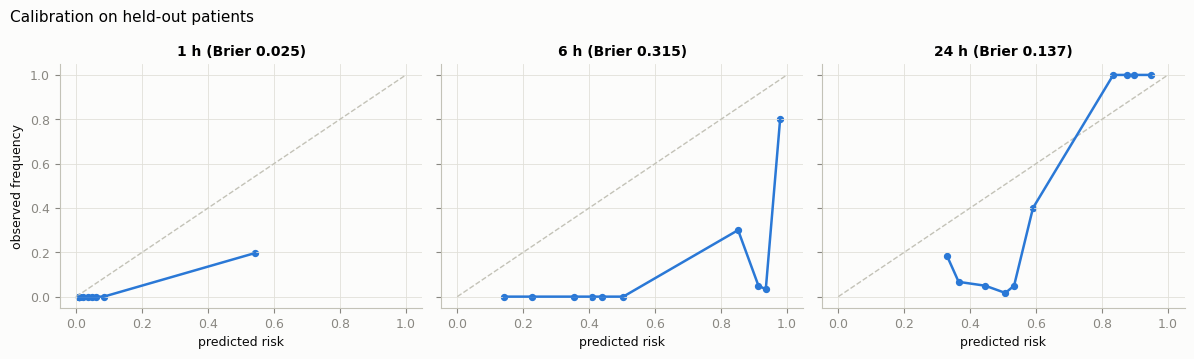

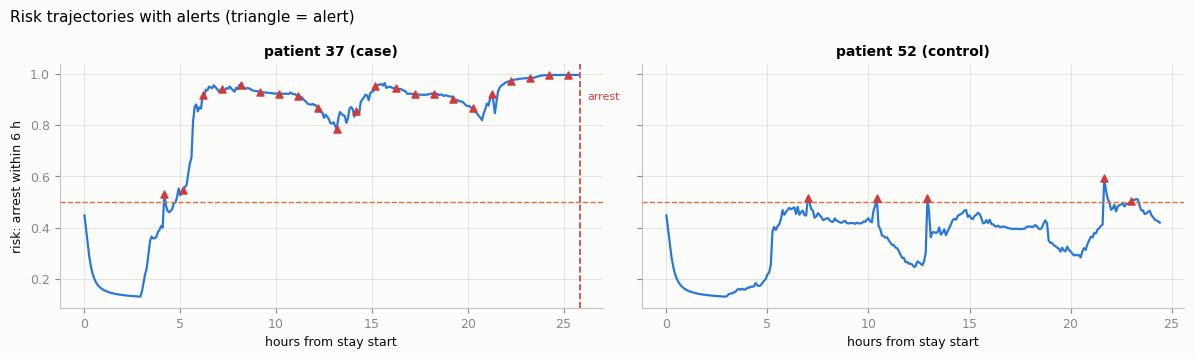

In [18]:
# ---------------------------------------------------------------------------
# Section 8 - Full evaluation on the held-out replay patients
# ---------------------------------------------------------------------------
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             roc_auc_score, roc_curve)
from sklearn.utils import resample

from ews_risk import simulate_patient

# pooled features + predictions for the replay patients (step=1: every window)
replay_feats_full = np.stack([build_features(replay_meta.iloc[i], eng_replay_vals[i],
                                             emb["replay_ecg"][i], emb["replay_ppg"][i])
                              for i in range(len(replay_meta))]).astype(np.float32)
zr = (replay_feats_full - pipe.feat_mean) / (pipe.feat_std + 1e-8)
lab_r = {}
tte_r = (replay_meta["arrest_h"] - replay_meta["t_end_h"]).to_numpy()
for H in HORIZONS:
    lab_r[H] = np.where(np.isnan(tte_r), 0, ((tte_r > 0) & (tte_r <= H)).astype(int))
Xr, Lr, Yr, Tr = make_sequences(replay_meta, zr, lab_r, tte_r, step=1)
with torch.no_grad():
    rout = pipe.model(torch.from_numpy(Xr), torch.from_numpy(Lr))
probs = {H: torch.sigmoid(rout["risk"][H]).numpy() for H in HORIZONS}
patients_r = replay_meta.patient_id.to_numpy()


def patient_bootstrap(metric_fn, y, p, n_iter=1000):
    """Patient-level bootstrap confidence interval (plan rule 8)."""
    stats = []
    for _ in range(n_iter):
        pids = resample(np.unique(patients_r))
        m = np.isin(patients_r, pids)
        if y[m].sum() > 0 and (y[m] == 0).sum() > 0:
            stats.append(metric_fn(y[m], p[m]))
    if not stats:
        return np.nan, np.nan, np.nan
    lo, hi = np.percentile(stats, [2.5, 97.5])
    return float(np.mean(stats)), float(lo), float(hi)


replay_metrics = {"per_horizon": {}}
print("Discrimination on held-out patients (mean [95% patient-bootstrap CI]):")
for H in HORIZONS:
    a, alo, ahi = patient_bootstrap(roc_auc_score, lab_r[H], probs[H])
    ap, aplo, aphi = patient_bootstrap(average_precision_score, lab_r[H], probs[H])
    br = brier_score_loss(lab_r[H], probs[H])
    replay_metrics["per_horizon"][f"{H}h"] = {
        "auroc": [a, alo, ahi], "auprc": [ap, aplo, aphi], "brier": br,
        "n_pos": int(lab_r[H].sum()), "n_neg": int((lab_r[H] == 0).sum())}
    print(f"  {H:>2}h (pos {lab_r[H].sum():>3}): AUROC {a:.3f} [{alo:.3f}, {ahi:.3f}] | "
          f"AUPRC {ap:.3f} [{aplo:.3f}, {aphi:.3f}] | Brier {br:.3f}")

# --- PPV at fixed sensitivity + sensitivity at a fixed alert budget ---------
print("\nAlert-level metrics (6 h horizon, no refractory for these thresholds):")
for H in HORIZONS:
    fpr, tpr, thr = roc_curve(lab_r[H], probs[H])
    idx80 = np.where(tpr >= 0.8)[0]
    if len(idx80):
        k = int(idx80[0])                               # threshold at sensitivity 0.8
        tp = tpr[k] * (lab_r[H] == 1).sum()
        fp = fpr[k] * (lab_r[H] == 0).sum()
        ppv80 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    else:
        ppv80 = float("nan")
    budget = 1.0 / 288.0                                # 1 alert per patient-day
    thr_b = float(np.quantile(probs[H], 1 - budget))
    alerted_b = probs[H] >= thr_b
    sens_b = float(lab_r[H][alerted_b].mean()) if alerted_b.any() and lab_r[H][alerted_b].size else 0.0
    replay_metrics.setdefault("ppv_at_sens08", {})[f"{H}h"] = ppv80
    replay_metrics.setdefault("sens_at_1alert_day", {})[f"{H}h"] = sens_b
    print(f"  {H:>2}h: PPV at sensitivity 0.8 = {ppv80:.3f} | "
          f"sensitivity at 1 alert/day = {sens_b:.3f}")

# --- lead-time distribution + time-averaged AUC across lead-time bins --------
alert_summary = {}
lead_times = []
for pid, g in replay_meta.groupby("patient_id"):
    windows = [{"t_h": float(replay_meta.at[pos, "t_start_h"]),
                "feats": build_features(replay_meta.iloc[pos], eng_replay_vals[pos],
                                        emb["replay_ecg"][pos], emb["replay_ppg"][pos])}
               for pos in g.index]
    steps = list(simulate_patient(pipe, windows))
    alerts = [s for s in steps if s["alert"]]
    is_case = bool(g["is_case"].iloc[0])
    arrest_h = float(g["arrest_h"].iloc[0]) if is_case else None
    if is_case:
        for a in alerts:
            if a["t_h"] < arrest_h:
                lead_times.append(arrest_h - a["t_h"])
    alert_summary[int(pid)] = {
        "is_case": is_case, "n_alerts": len(alerts),
        "stay_h": len(windows) * WINDOW_MIN / 60,
        "alerts_per_day": len(alerts) / (len(windows) * WINDOW_MIN / 60) * 24}
print(f"\nLead time of true alerts: {len(lead_times)} alerts | "
      + (f"min {min(lead_times):.1f} h, median {np.median(lead_times):.1f} h, "
         f"max {max(lead_times):.1f} h" if lead_times else "none"))
replay_metrics["lead_time_h"] = sorted(lead_times)
replay_metrics["alerts"] = alert_summary

bins = [(0, 1), (1, 6), (6, 24)]
tavg = []
for lo, hi in bins:
    pos = np.isfinite(tte_r) & (tte_r > lo) & (tte_r <= hi)
    if pos.sum() == 0:
        continue
    y = pos.astype(int)
    tavg.append(roc_auc_score(y, probs[24]))
tavg_auc = float(np.mean(tavg))
print(f"time-averaged AUC across lead-time bins (0-1/1-6/6-24 h, 24 h head): "
      f"{tavg_auc:.3f}")
replay_metrics["time_avg_auc_leadtime"] = tavg_auc

# --- failure-case review tables ----------------------------------------------
is_case_r = replay_meta["is_case"].to_numpy().astype(bool)
case_pos = np.where(is_case_r)[0]
arrest_h_r = float(replay_meta["arrest_h"].iloc[case_pos[0]])
near = case_pos[replay_meta["t_start_h"].to_numpy()[case_pos] >= arrest_h_r - 3.0]
miss_pos = [p for p in near if probs[6][p] < 0.5]
misses = replay_meta.iloc[miss_pos][["patient_id", "t_start_h", "hr", "sbp", "spo2"]].copy()
misses["risk_6h"] = probs[6][miss_pos].round(3)
misses["tte_h"] = tte_r[miss_pos].round(1)
print(f"\nFailure review - windows within 3 h of arrest missed (risk_6h < 0.5): "
      f"{len(misses)}")
print(misses.to_string(index=False))

ctrl_pos = np.where(~is_case_r)[0]
top_fa = sorted(ctrl_pos, key=lambda p: -probs[6][p])[:5]
fas = replay_meta.iloc[top_fa][["patient_id", "t_start_h", "hr", "sbp", "spo2"]].copy()
fas["risk_6h"] = probs[6][top_fa].round(3)
print(f"\nFailure review - top-5 false-alarm windows on the control patient:")
print(fas.to_string(index=False))

# --- figures: calibration + risk trajectories --------------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, H in zip(axes, HORIZONS):
    order = np.argsort(probs[H])
    n_bins = 10
    edges = np.linspace(0, len(order), n_bins + 1).astype(int)
    obs, pred = [], []
    for a, b in zip(edges[:-1], edges[1:]):
        idx = order[a:b]
        pred.append(probs[H][idx].mean())
        obs.append(lab_r[H][idx].mean())
    ax.plot([0, 1], [0, 1], color="#c3c2b7", linestyle="--", linewidth=1)
    ax.plot(pred, obs, color=COLORS["blue"], linewidth=1.8)
    ax.scatter(pred, obs, s=18, color=COLORS["blue"])
    ax.set_title(f"{H} h (Brier {brier_score_loss(lab_r[H], probs[H]):.3f})")
    ax.set_xlabel("predicted risk")
axes[0].set_ylabel("observed frequency")
fig.suptitle("Calibration on held-out patients", fontsize=11, x=0.01, ha="left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_eval_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, (pid, g) in zip(axes, replay_meta.groupby("patient_id")):
    windows = [{"t_h": float(replay_meta.at[pos, "t_start_h"]),
                "feats": build_features(replay_meta.iloc[pos], eng_replay_vals[pos],
                                        emb["replay_ecg"][pos], emb["replay_ppg"][pos])}
               for pos in g.index]
    steps = list(simulate_patient(pipe, windows))
    t = [s["t_h"] for s in steps]
    r = [s["risk"][6] for s in steps]
    ax.plot(t, r, color=COLORS["blue"], linewidth=1.6)
    ax.axhline(pipe.threshold, color=COLORS["orange"], linewidth=1, linestyle="--",
               label="alert threshold")
    for s in steps:
        if s["alert"]:
            ax.scatter(s["t_h"], s["risk"][6], s=26, color=COLORS["critical"],
                       zorder=5, marker="^")
    if bool(g["is_case"].iloc[0]):
        ah = float(g["arrest_h"].iloc[0])
        ax.axvline(ah, color=COLORS["critical"], linewidth=1.2, linestyle="--")
        ax.text(ah + 0.4, 0.9, "arrest", color=COLORS["critical"], fontsize=8)
    ax.set_title(f"patient {int(pid)} ({'case' if bool(g['is_case'].iloc[0]) else 'control'})")
    ax.set_xlabel("hours from stay start")
axes[0].set_ylabel("risk: arrest within 6 h")
fig.suptitle("Risk trajectories with alerts (triangle = alert)", fontsize=11,
             x=0.01, ha="left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_eval_risk_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()


In [19]:
# ---------------------------------------------------------------------------
# Section 8 - Ablations: which feature block carries the signal?
# (variants retrained with the same patient-level split; cached)
# ---------------------------------------------------------------------------
from ews_risk import mask_blocks

ABLATE_DIR = CACHE_DIR / "models" / "ablations"
variants = {
    "full":              dict(use_eng=True,  use_emb=True),
    "vitals_only":       dict(use_eng=False, use_emb=False),
    "vitals+engineered": dict(use_eng=True,  use_emb=False),
    "vitals+embeddings": dict(use_eng=False, use_emb=True),
}


def train_variant(name, use_eng, use_emb, epochs=20):
    f = ABLATE_DIR / f"{name}.pt"
    if f.exists():
        m = FEAN()
        m.load_state_dict(torch.load(f)["model"])
        m.eval()
        return m
    m = FEAN()
    opt = torch.optim.Adam(m.parameters(), lr=2e-3)
    Xtr_v, Ltr_v, Ytr_v, Ttr_v = make_sequences(
        train_meta.loc[tr_mask], mask_blocks(z[tr_mask], use_eng, use_emb),
        {H: labels[H][tr_mask] for H in HORIZONS}, tte[tr_mask])
    pos_w = {H: float((Ytr_v[H] == 0).sum() / max(1, (Ytr_v[H] == 1).sum()))
             for H in HORIZONS}
    for _ in range(epochs):
        m.train()
        opt.zero_grad()
        out = m(torch.from_numpy(Xtr_v), torch.from_numpy(Ltr_v))
        loss = sum(F.binary_cross_entropy_with_logits(
                       out["risk"][H], torch.from_numpy(Ytr_v[H]),
                       pos_weight=torch.tensor(pos_w[H]))
                   for H in HORIZONS)
        pos = Ytr_v[24] == 1
        if pos.any():
            loss = loss + 0.1 * F.mse_loss(out["tte_norm"][pos],
                                           torch.from_numpy(Ttr_v[pos] / 24.0))
        loss.backward()
        opt.step()
    m.eval()
    ABLATE_DIR.mkdir(parents=True, exist_ok=True)
    torch.save({"model": m.state_dict()}, f)
    return m


def variant_val_auc(m):
    with torch.no_grad():
        out = m(torch.from_numpy(Xva), torch.from_numpy(Lva))
    return {H: roc_auc_score(Yva[H], torch.sigmoid(out["risk"][H]).numpy())
            for H in HORIZONS}


def variant_replay(m, name):
    """Alert stats of a variant on the held-out replay patients."""
    zr_v = mask_blocks(zr, **variants[name])
    Xr_v, Lr_v, Yr_v, Tr_v = make_sequences(replay_meta, zr_v, lab_r, tte_r, step=1)
    with torch.no_grad():
        out = m(torch.from_numpy(Xr_v), torch.from_numpy(Lr_v))
    pr = {H: torch.sigmoid(out["risk"][H]).numpy() for H in HORIZONS}
    stats = {}
    for pid, g in replay_meta.groupby("patient_id"):
        alerts = 0
        true = 0
        for pos in g.index:
            risk = pr[6][pos]
            if risk >= pipe.threshold:
                alerts += 1
                if bool(g["is_case"].iloc[0]):
                    true += 1
        stats[int(pid)] = {"alerts": alerts, "true": true}
    return stats


ablation_summary = {}
for name, kw in variants.items():
    m = train_variant(name, **kw)
    va = variant_val_auc(m)
    ra = variant_replay(m, name)
    ablation_summary[name] = {"val_auroc": va, "replay_alerts": ra}
    print(f"{name:<18} val AUROC " + "  ".join(f"{H}h={a:.3f}" for H, a in va.items()) +
          " | replay alerts " + ", ".join(f"p{pid}: {s['alerts']}" for pid, s in ra.items()))


full               val AUROC 1h=1.000  6h=0.859  24h=0.619 | replay alerts p37: 247, p52: 1


vitals_only        val AUROC 1h=1.000  6h=0.755  24h=0.555 | replay alerts p37: 38, p52: 0


vitals+engineered  val AUROC 1h=1.000  6h=0.845  24h=0.718 | replay alerts p37: 51, p52: 0


vitals+embeddings  val AUROC 1h=1.000  6h=0.816  24h=0.574 | replay alerts p37: 245, p52: 0


## Section 9 (optional) — Slow-risk layer: skipped

The plan's optional weeks-to-months risk layer uses ECG-SCD on the Nightingale NTUH dataset. Skipped: it needs a separate Python 3.12 environment and credentialed Nightingale access, and the plan says to keep it separate from the short-horizon model. Revisit only after real short-horizon data is available.


## Section 10 — Export

Metrics, figures, config, and third-party commit hashes land in `outputs/`.


In [20]:
# ---------------------------------------------------------------------------
# Section 10 - Export metrics + run info to outputs/
# ---------------------------------------------------------------------------
import json
from datetime import datetime

repos = {
    "ecg-fm": THIRD_PARTY_DIR / "ecg-fm",
    "fairseq-signals": THIRD_PARTY_DIR / "fairseq-signals",
    "papagei-foundation-model": THIRD_PARTY_DIR / "papagei-foundation-model",
    "pulseppg": THIRD_PARTY_DIR / "pulseppg",
}
export = {
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "disclaimer": "research prototype on synthetic data - not clinically validated",
    "config": {
        "use_synthetic": USE_SYNTHETIC, "random_seed": RANDOM_SEED,
        "horizons": HORIZONS, "n_patients": N_PATIENTS, "p_arrest": P_ARREST,
        "drift_h": DRIFT_H, "window_min": WINDOW_MIN, "seq_len_windows": SEQ_LEN,
        "alert": {"horizon_h": pipe.alert_horizon, "threshold": pipe.threshold,
                  "refractory_min": pipe.refractory_min},
    },
    "data": {"patients": int(len(inventory)), "windows": int(len(vitals)),
             "events": int(len(events))},
    "splits": {"val_patients": sorted(int(p) for p in val_pids),
               "replay_patients": sorted(int(p) for p in set(replay_meta.patient_id))},
    "metrics": {
        "baselines": baseline_results,
        "fean_val_auroc": {f"{H}h": auc[H] for H in HORIZONS},
        "replay": replay_metrics,
        "ablations": ablation_summary,
    },
    "third_party_commits": {k: repo_commit(p) for k, p in repos.items()},
    "environment": {"python": sys.version.split()[0]},
}
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(export, indent=1, default=str))
print(f"exported -> {OUTPUT_DIR / 'metrics.json'}")
print("figures in outputs/: sanity_trajectory.png, sanity_waveforms.png, "
      "fig_eval_calibration.png, fig_eval_risk_trajectory.png")
print("\nNOTE: all metrics are a synthetic-data pipeline demonstration "
      "(plan rule 8) - not clinical evidence.")


exported -> /home/abrar/Desktop/AI RPM Papers/Cardiac Arrest Detection/outputs/metrics.json
figures in outputs/: sanity_trajectory.png, sanity_waveforms.png, fig_eval_calibration.png, fig_eval_risk_trajectory.png

NOTE: all metrics are a synthetic-data pipeline demonstration (plan rule 8) - not clinical evidence.


## Remaining work (beyond this notebook)

- **Real data**: MIMIC-III / MIMIC-IV waveforms + MIMIC-III-Ext-CA arrest annotations (credentialed PhysioNet access); the synthetic cohort is a stand-in.
- **GPU embedding**: embed the full 42k-window cohort (CPU-bound here; ~0.1 s/ECG segment).
- **v2 of the temporal model** (after v1 works): identity-adversarial head with gradient reversal, PCGrad for multi-task conflicts.
- **Optional Section 9** slow-risk layer (ECG-SCD / Nightingale NTUH) - separate environment and dataset access.

The notebook runs the demo end-to-end: config → synthetic cohort → labels → preprocessing → engineered features → baselines → embeddings (ECG-FM + PaPaGei) → Wav2Arrest-style risk model → ablation → alert simulation and evaluation on held-out patients → export.
